Random Forest Model

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report, balanced_accuracy_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# use cvd risk level not cvd risk score
# blood pressure categories found from https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings
# remove systolic, diastolic, and blood pressure, just keep blood pressure category (determined by systolic over diastolic values)

df = pd.read_csv('cvd_dataset.csv').dropna(subset=['CVD Risk Score'])
df_male = pd.read_csv('male_cvd_dataset.csv').dropna()
df_female = pd.read_csv('female_cvd_dataset.csv').dropna()

def dataset_rev(df):
    df_edited = df.drop(columns=['Blood Pressure (mmHg)','Systolic BP','Diastolic BP'])

    # ordinal encoding categories
    sex_categories = ['F','M'] 
    physical_activity_categories = ['Low','Moderate','High']
    blood_pressure_categories = ['Normal','Elevated','Hypertension Stage 1','Hypertension Stage 2']
    # smoking, diabetes, family history all Y/N (0,1)
    yn_categories = ['Y','N']
    # cvd risk levels (0,1,2)
    risk_categories = ['LOW','INTERMEDIARY','HIGH']

    encoder = OrdinalEncoder(categories=[sex_categories, physical_activity_categories, blood_pressure_categories, yn_categories, yn_categories, yn_categories,risk_categories])
    df_edited[['Sex','Physical Activity Level','Blood Pressure Category','Smoking Status','Diabetes Status','Family History of CVD','CVD Risk Level']] = encoder.fit_transform(df_edited[['Sex','Physical Activity Level','Blood Pressure Category','Smoking Status','Diabetes Status','Family History of CVD','CVD Risk Level']])

    X = df_edited.drop(columns=['CVD Risk Level','CVD Risk Score'])
    y = df_edited['CVD Risk Level']

    return X, y

fem_X, fem_y = dataset_rev(df_female)
male_X, male_y = dataset_rev(df_male)
X,y = dataset_rev(df)

In [12]:
def graph_vis(all_y_true,all_y_pred):
    cm = confusion_matrix(all_y_true, all_y_pred)
    df_preds = pd.DataFrame({"True": [int(x) for x in all_y_true],
                            "Predicted": all_y_pred})

    sns.countplot(x="True", data=df_preds, label="True", color="skyblue")
    sns.countplot(x="Predicted", data=df_preds, label="Predicted", color="salmon", alpha=0.6)
    plt.legend()
    plt.title("Distribution of True vs Predicted Labels")
    plt.show()

1 :  0.75
2 :  0.75
3 :  0.75
4 :  0.5
5 :  0.625
6 :  0.875
7 :  0.625
8 :  0.625
9 :  0.875
10 :  0.5
11 :  0.875
12 :  0.625
13 :  0.625
14 :  0.375
15 :  0.375
16 :  0.25
17 :  0.5
18 :  0.5
19 :  0.375
20 :  0.625
21 :  0.125
22 :  0.625
23 :  0.625
24 :  0.625
25 :  0.625
26 :  0.75
27 :  0.875
28 :  0.75
29 :  0.5
30 :  0.625
31 :  0.625
32 :  0.625
33 :  0.625
34 :  0.375
35 :  0.625
36 :  0.5
37 :  0.5
38 :  0.75
39 :  0.625
40 :  0.375
41 :  0.875
42 :  0.625
43 :  0.5
44 :  0.625
45 :  0.42857142857142855
46 :  0.8571428571428571
47 :  0.5714285714285714
48 :  0.7142857142857143
49 :  0.8571428571428571
50 :  0.7142857142857143
              precision    recall  f1-score   support

         LOW       0.11      0.02      0.03        51
INTERMEDIARY       0.62      0.58      0.60       152
        HIGH       0.62      0.79      0.70       191

    accuracy                           0.61       394
   macro avg       0.45      0.46      0.44       394
weighted avg       0.55    

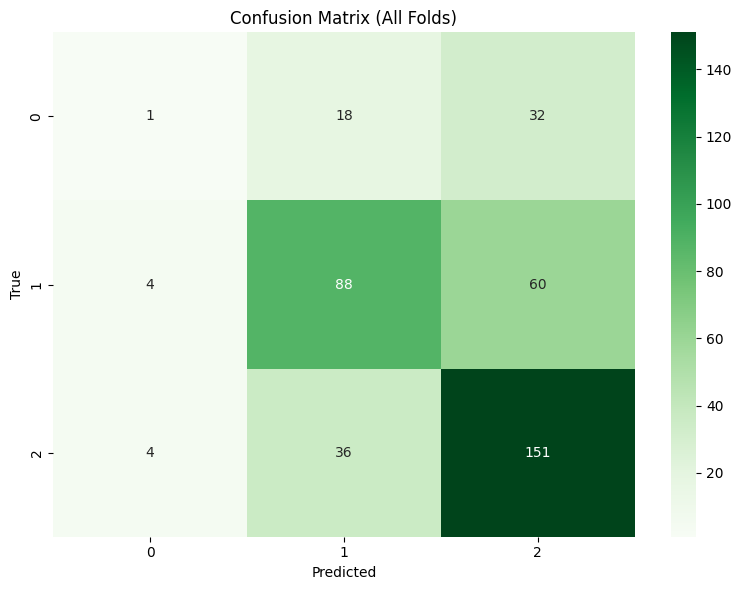

Cross-Validation Results (Accuracy):
  Fold 1: 75.00%
  Fold 2: 75.00%
  Fold 3: 75.00%
  Fold 4: 50.00%
  Fold 5: 62.50%
  Fold 6: 87.50%
  Fold 7: 62.50%
  Fold 8: 62.50%
  Fold 9: 87.50%
  Fold 10: 50.00%
  Fold 11: 87.50%
  Fold 12: 62.50%
  Fold 13: 62.50%
  Fold 14: 37.50%
  Fold 15: 37.50%
  Fold 16: 25.00%
  Fold 17: 50.00%
  Fold 18: 50.00%
  Fold 19: 37.50%
  Fold 20: 62.50%
  Fold 21: 12.50%
  Fold 22: 62.50%
  Fold 23: 62.50%
  Fold 24: 62.50%
  Fold 25: 62.50%
  Fold 26: 75.00%
  Fold 27: 87.50%
  Fold 28: 75.00%
  Fold 29: 50.00%
  Fold 30: 62.50%
  Fold 31: 62.50%
  Fold 32: 62.50%
  Fold 33: 62.50%
  Fold 34: 37.50%
  Fold 35: 62.50%
  Fold 36: 50.00%
  Fold 37: 50.00%
  Fold 38: 75.00%
  Fold 39: 62.50%
  Fold 40: 37.50%
  Fold 41: 87.50%
  Fold 42: 62.50%
  Fold 43: 50.00%
  Fold 44: 62.50%
  Fold 45: 42.86%
  Fold 46: 85.71%
  Fold 47: 57.14%
  Fold 48: 71.43%
  Fold 49: 85.71%
  Fold 50: 71.43%


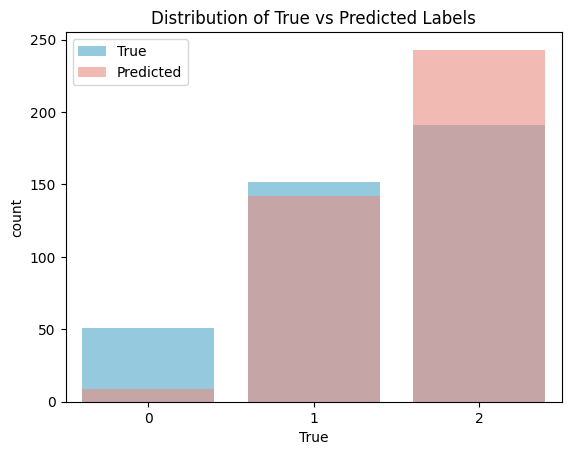

In [ ]:
kf = StratifiedKFold(n_splits=50,shuffle=True,random_state=42)
metrics = []
all_y_true = []
all_y_pred = []

RandomForestClassifier(n_estimators=500,
    class_weight="balanced",
    random_state=42,
    max_depth=None
)

fold_num = 1
for train_index, test_index in kf.split(fem_X,fem_y): # splits dataset into stratified train-test indices
    X_train, X_test = fem_X.iloc[train_index], fem_X.iloc[test_index] # features
    y_train, y_test = fem_y.iloc[train_index], fem_y.iloc[test_index] # labels
    
    random_forest = RandomForestClassifier(random_state=42)
    random_forest.fit(X_train, y_train)

    y_pred = random_forest.predict(X_test).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    print(fold_num, ': ',accuracy)
    fold_num += 1
    metrics.append(accuracy)
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

print(classification_report(all_y_true, all_y_pred, target_names=encoder.categories_[6]))
cm = confusion_matrix(all_y_true, all_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (All Folds)')
plt.tight_layout()
plt.show()

print("Cross-Validation Results (Accuracy):")
for i, result in enumerate(metrics, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")

graph_vis(all_y_true,all_y_pred)

In [26]:
print(y.value_counts(normalize=True))

CVD Risk Level
2.0    0.482940
1.0    0.375328
0.0    0.141732
Name: proportion, dtype: float64
